## Preamble

In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

In [4]:
def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(nr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[24:24+nz,24:24+nx,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWI',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

## Numeric test by Robertsson, Fig 1,2, vz force

In [3]:
nz=241; nx=241; h=5
nzsnap=289; nxsnap=289; nsnap=51

fpeak=15

dt=0.0004
nt=2500
t=np.arange(0,nt*dt,dt)-0.067

nr=1

In [6]:
vs =1730*np.ones((nz,nx))
rho=2500*np.ones((nz,nx))

vs.T.astype('float32').tofile('vs')
rho.T.astype('float32').tofile('rho')
!cat vs rho > model

In [7]:
!cat setup_default

MODEL_SIZE              '241   241   1'
MODEL_SPACING           '5     5     1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'vs rho'

ACQUI_GEOMETRY          spread
FS                      ' 0   100 0'
FR                      '30  1100 0'
DR                      ' 0     0 0'
NR                       1

SCOMP                    vy
RCOMP                   'vy szy sxy'

NT           2500
DT           0.0004
WAVELET_TYPE ricker
FPEAK        15

SNAPSHOT      'vy szy sxy'

IF_USE_CHECKPOINT   F


#why the vz comp of dsyn is weird?


### Modeling w/o free surface

In [26]:
!cp setup_default setup
!echo "IF_HICKS  F" >> setup
run(app='../../exe/fwd_SH_FDSG_O4_')

./run.sh: line 1: ulimit: stack size: cannot modify limit: Operation not permitted
 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/Users/wzhou/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxr-xr-x@ 1 wzhou  staff  1726972  2  2 02:08 ../../exe/fwd_SH_FDSG_O4_
 Git Commit: ee83391
 Git Branch: SH
 Compiler: gfortran v15.2.0
 Version: 15.2.0
 Endianness:         1234
 System date: 02/02/2026
System time: 02:08:29
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D SH wave propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference

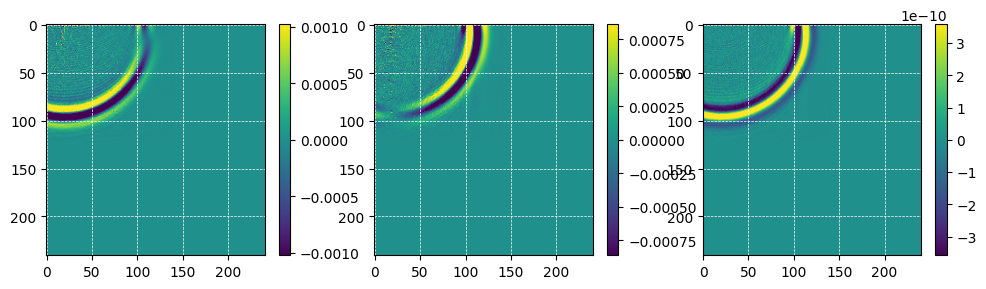

In [28]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results/snap_fld_u%szy'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results/snap_fld_u%sxy'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results/snap_fld_u%vy' ),perc=98)

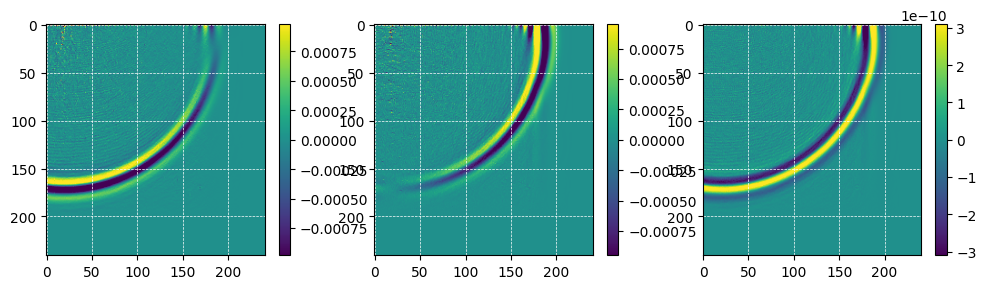

In [29]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results/snap_fld_u%szy',i=28),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results/snap_fld_u%sxy',i=28),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results/snap_fld_u%vy' ,i=28),perc=98)

### Modeling w/ free surface

In [27]:
!cp setup_default setup
!echo "IF_HICKS  F" >> setup
run(app='../../exe/fwd_SH_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_DAS_Freesurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 668168 Mar 24 23:12 ../../exe/fwd_DAS_FDSG_O4_
 Git Commit: 268cd13
 Git Branch: DAS_FS
 Compiler: gfortran v11.4.0
 Version: 11.4.0
 Endianness:         1234
 System date: 03/24/2024
System time: 23:17:05
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PE
 Output directory:res_PE/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Momemtum-Strain formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.

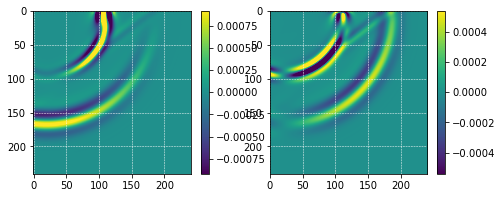

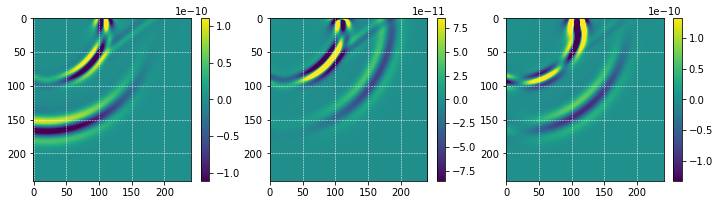

In [28]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PE/snap_fld_u%pz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PE/snap_fld_u%px'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PE/snap_fld_u%ez'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PE/snap_fld_u%ex'),perc=98)
plt.subplot(1,3,3); imshow(read_snap('res_PE/snap_fld_u%es'),perc=98)

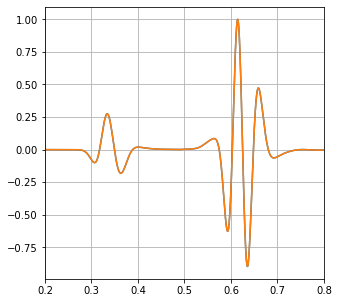

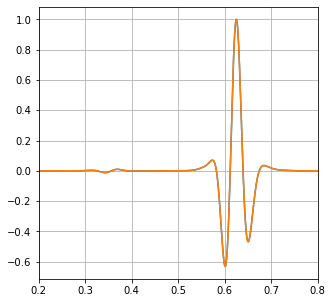

In [29]:
plt.figure(figsize=(5,5))
tr=read_su('res_VS/Ru_Shot0001.su',n=(3,nt))[:,1] ; plt.plot(t,tr/np.amax(tr))
tr=read_su('res_PE/Ru_Shot0001.su',n=(2,nt))[:,1] ; plt.plot(t,tr/np.amax(tr))
plt.xlim([0.2,0.8]); plt.grid()

plt.figure(figsize=(5,5))
tr=read_su('res_VS/Ru_Shot0001.su',n=(3,nt))[:,0] ; plt.plot(t,tr/np.amax(tr))
tr=read_su('res_PE/Ru_Shot0001.su',n=(2,nt))[:,0] ; plt.plot(t,tr/np.amax(tr))
plt.xlim([0.2,0.8]); plt.grid()